name
only_threshold        7
sing.link.           11
with_threshold        6
without_threshold    14
Name: loss, dtype: int64


Text(0.5, 0, 'cluster counts')

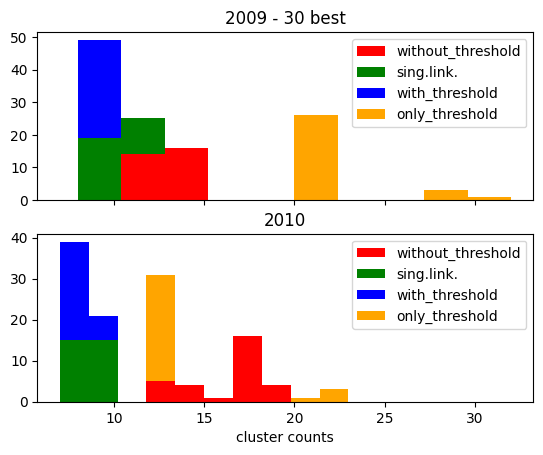

In [1]:

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kmapper as km
from sklearn.cluster import AgglomerativeClustering
from customClustering import  DynamicSingleLinkage
from hyperparam_optimization import (
    apply_func_to_year_dict_on_key, apply_func_to_year_dict_on_value, apply_func_to_year_dict_on_item,
    apply_func_to_nested_grouping, ClusteringPreperation, ClusterPipeline,
    add_cbar_right_of_axis
    )

opti_results = pd.read_csv("../data/opti_results_26-06-26_16-46.csv").sort_values("loss")
opti_results["params"] = opti_results["params"].apply(ast.literal_eval)
# short test if we actually have different optimization results
print(opti_results.groupby("name")["loss"].nunique())

names = opti_results["name"].unique()
colors = ["red","green","blue","orange"]

fig, axs = plt.subplots(2,1,sharex=True)

axs[0].hist(
    [
        opti_results["2009"][opti_results["name"]==name].head(30)
        for name in names],
    stacked=True,
    color=colors,
    label = names
)
axs[0].set_title("2009 - 30 best")
axs[0].legend()
axs[1].hist(
    [
        opti_results["2010"][opti_results["name"]==name].head(30)
        for name in names],
    stacked=True,
    color=colors,
    label = names
)
axs[1].set_title("2010")
axs[1].legend()
axs[1].set_xlabel("cluster counts")

In [2]:


#### load the data ####
df_data = pd.read_csv("../data/processed_data.csv")

#### define groupings ####
year_dates = {
    "2009": ('2009-01-01','2010-01-01'),
    "2010": ('2010-01-01','2011-01-01'),
}
sorted_year_keys = sorted(year_dates.keys(),key=int)
year_indx = apply_func_to_year_dict_on_key(
    year_dates,
    lambda year: sorted_year_keys.index(year)
)

clustering_data_per_year = apply_func_to_year_dict_on_item(
    year_dates,
    lambda year, bounds: ClusteringPreperation(df_data,year,bounds)
)

clusterer_generators = {
    "sing.link.": lambda eps: AgglomerativeClustering(
        distance_threshold=eps,
        n_clusters=None,
        linkage="single"),

    "only_threshold": lambda t_lm: DynamicSingleLinkage(
        lowerMergerThreshold = t_lm,
        epsilon_strategy="only_threshold"),
    
    "without_threshold": lambda N_bins: DynamicSingleLinkage(
        N_bins = N_bins,
        epsilon_strategy="without_threshold"),
    
    "with_threshold": lambda N_bins,t_lm: DynamicSingleLinkage(
        N_bins = N_bins,
        lowerMergerThreshold = t_lm,
        epsilon_strategy="with_threshold"),
}

mapper = km.KeplerMapper()
cover = km.Cover(
    n_cubes=120,
    perc_overlap=1-(1/4),
)

def build_clustering(clusterer_settings,name):
    return apply_func_to_year_dict_on_item(
        clustering_data_per_year,
        lambda year,clustering_data: ClusterPipeline(
            clustering_data,
            mapper,
            clusterer_generators[name](**clusterer_settings),
            cover, name, clusterer_settings
        )
    )


     Unnamed: 0  trial        name                       params  2009  2010  \
276         276     99  sing.link.  {'eps': 0.3859532740358038}    11    10   
192         192     99  sing.link.  {'eps': 0.3583727682363307}    10     9   
184         184     99  sing.link.  {'eps': 0.4028335873506871}    10     9   

     loss  
276    28  
192    28  
184    28  
     Unnamed: 0  trial        name                       params  2009  2010  \
276         276     99  sing.link.  {'eps': 0.3859532740358038}    11    10   
192         192     99  sing.link.  {'eps': 0.3583727682363307}    10     9   
184         184     99  sing.link.  {'eps': 0.4028335873506871}    10     9   

     loss  
276    28  
192    28  
184    28  


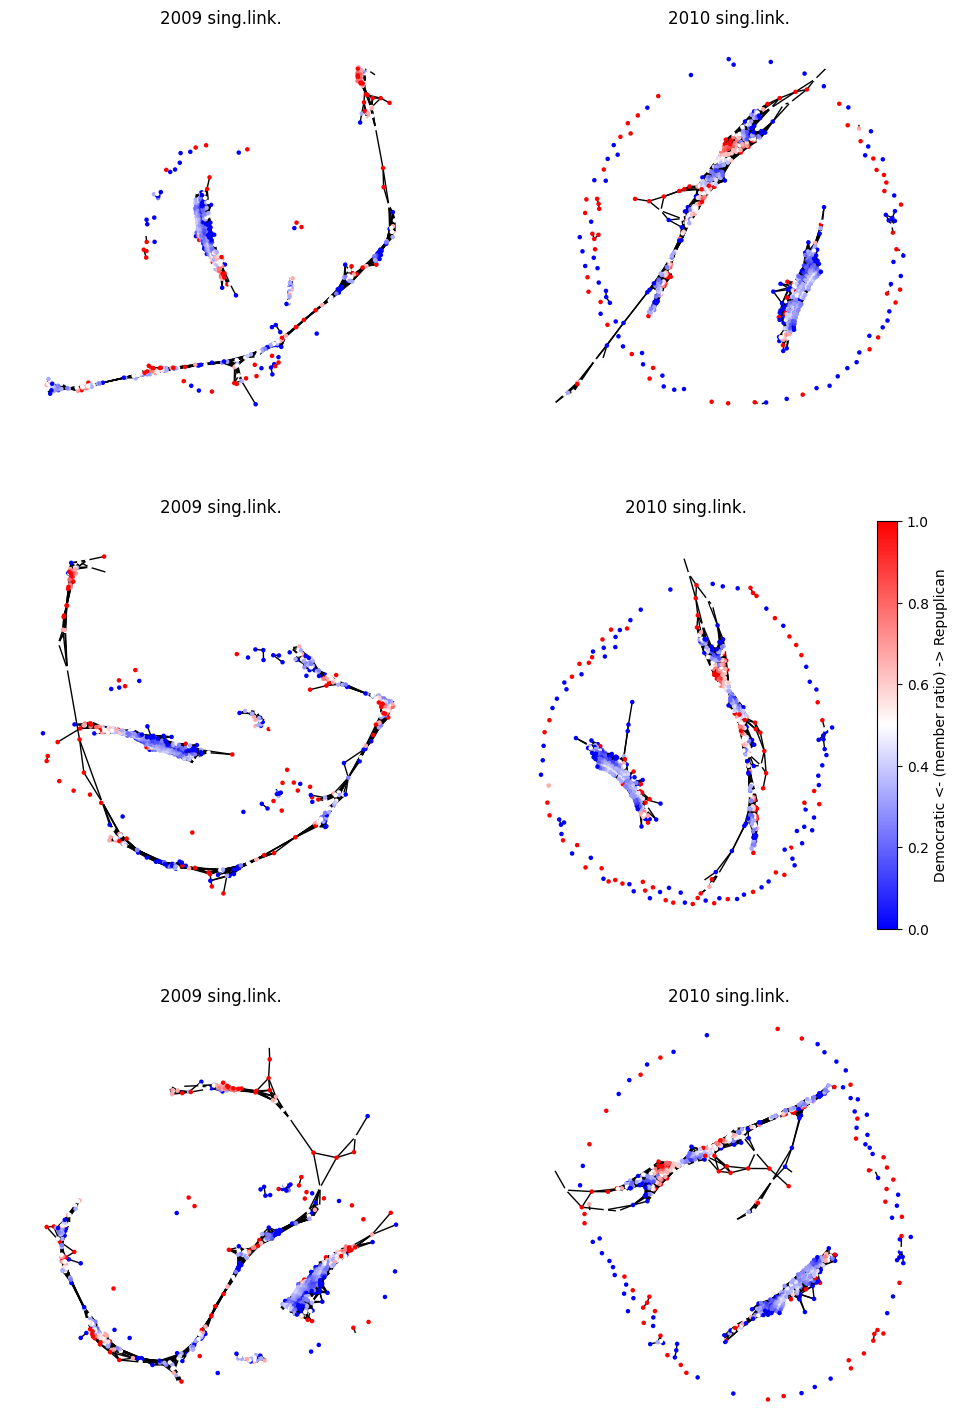

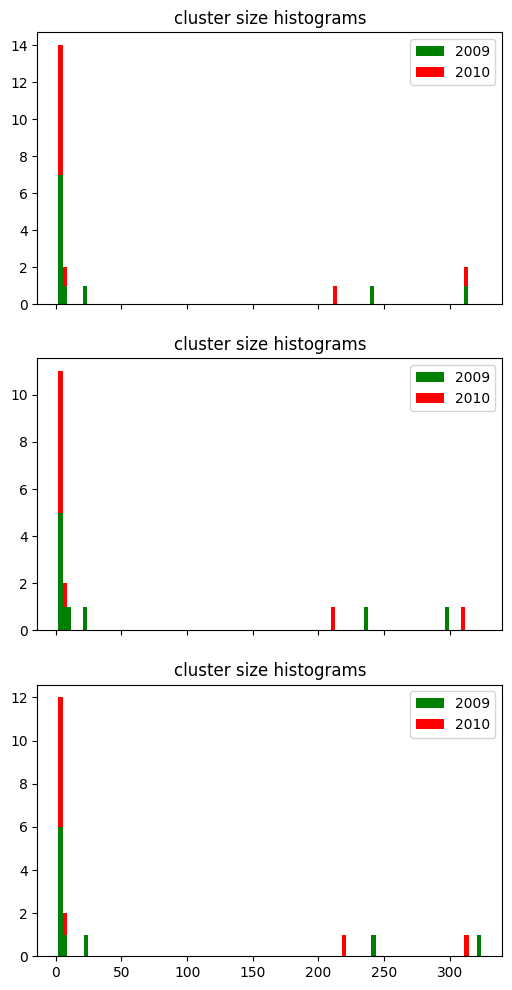

     Unnamed: 0  trial            name                         params  2009  \
53           53     99  only_threshold  {'t_lm': 0.12998991555807252}    29   
209         209     99  only_threshold  {'t_lm': 0.13035305523953494}    29   
285         285     99  only_threshold   {'t_lm': 0.7260977703398416}    21   

     2010  loss  
53     22    34  
209    22    34  
285    12    36  
     Unnamed: 0  trial            name                         params  2009  \
53           53     99  only_threshold  {'t_lm': 0.12998991555807252}    29   
209         209     99  only_threshold  {'t_lm': 0.13035305523953494}    29   
285         285     99  only_threshold   {'t_lm': 0.7260977703398416}    21   

     2010  loss  
53     22    34  
209    22    34  
285    12    36  


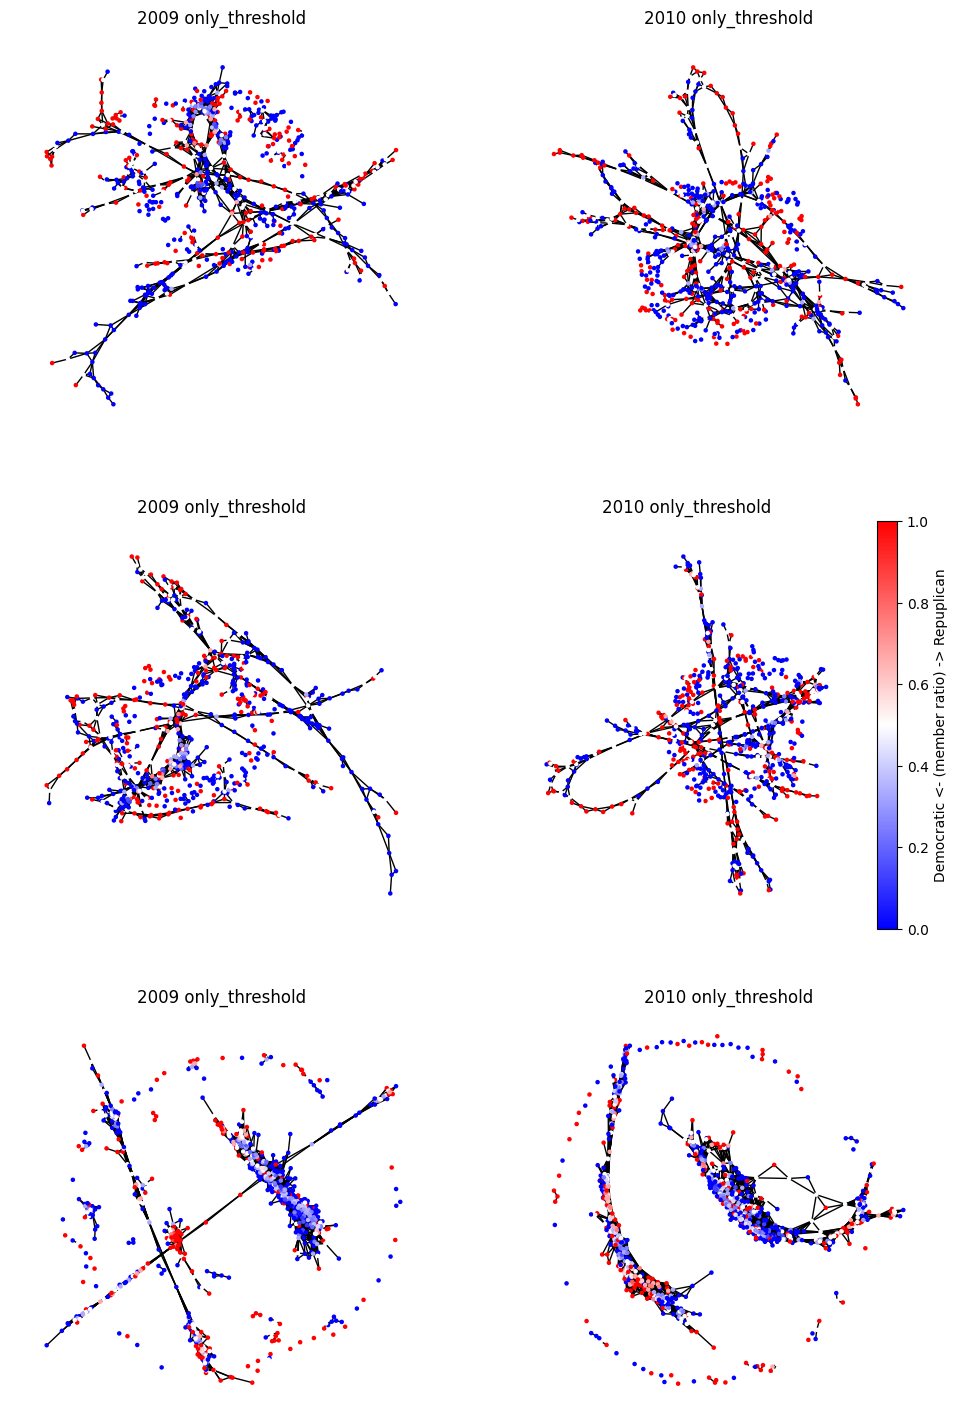

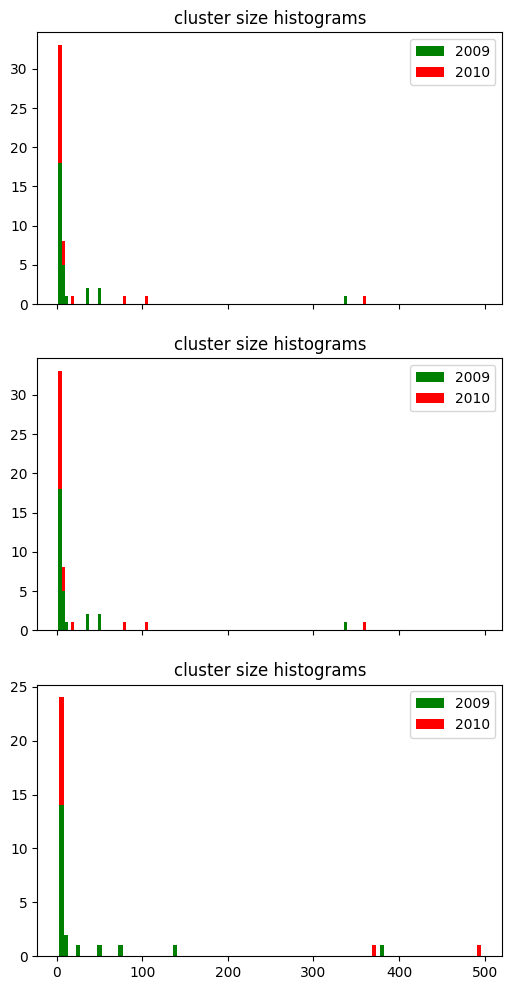

     Unnamed: 0  trial               name          params  2009  2010  loss
294         294     99  without_threshold  {'N_bins': 40}    11    19    19
362         362     99  without_threshold  {'N_bins': 40}    11    19    19
190         190     99  without_threshold  {'N_bins': 42}    11    19    19
     Unnamed: 0  trial               name          params  2009  2010  loss
294         294     99  without_threshold  {'N_bins': 40}    11    19    19
362         362     99  without_threshold  {'N_bins': 40}    11    19    19
190         190     99  without_threshold  {'N_bins': 42}    11    19    19


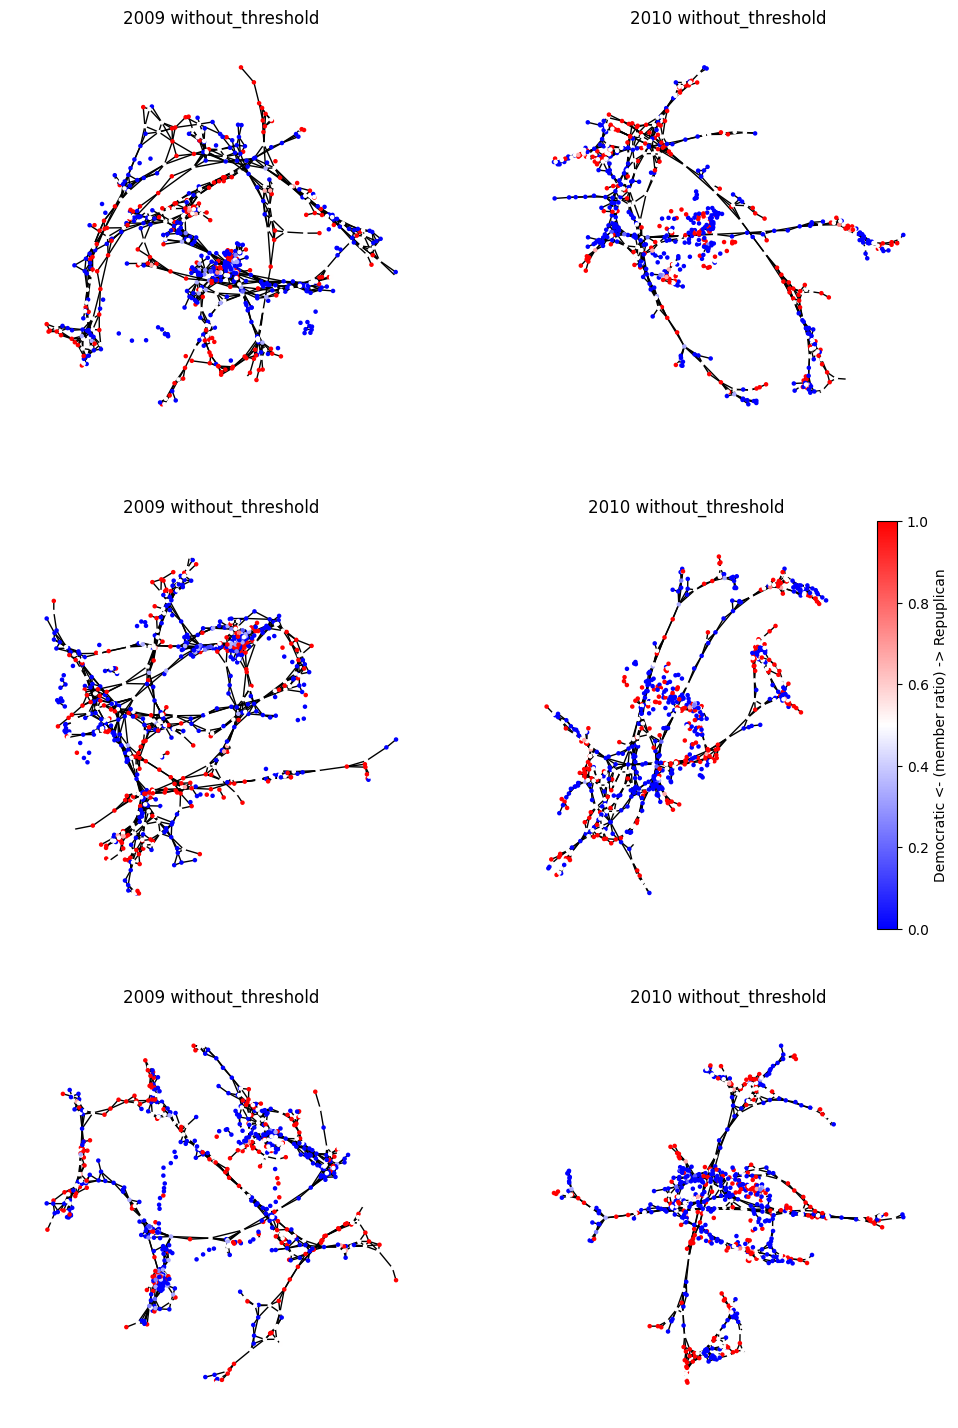

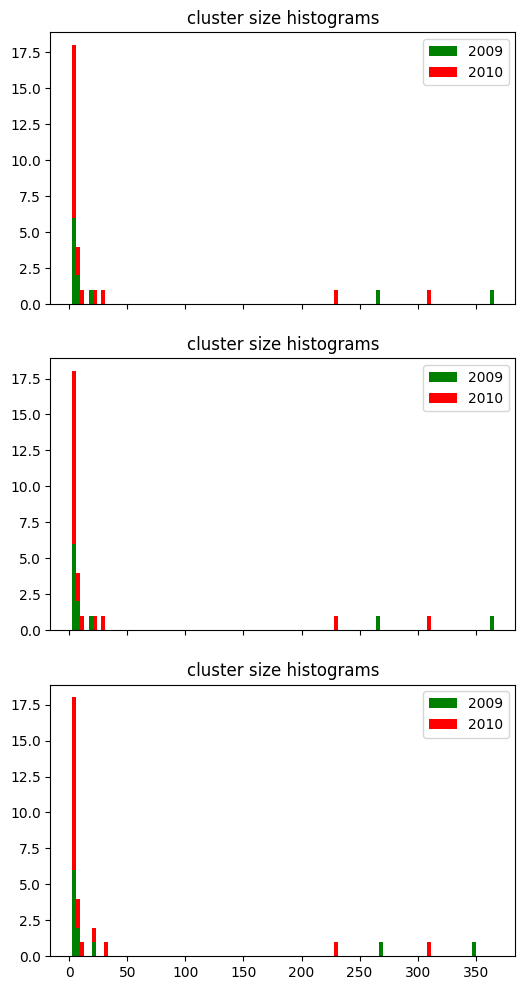

     Unnamed: 0  trial            name  \
103         103     99  with_threshold   
83           83     99  with_threshold   
247         247     99  with_threshold   

                                          params  2009  2010  loss  
103  {'N_bins': 44, 't_lm': 0.10407736825623477}     9    10    28  
83   {'N_bins': 47, 't_lm': 0.14868964337430032}     9     9    29  
247  {'N_bins': 28, 't_lm': 0.14411705936364827}     9     9    29  
     Unnamed: 0  trial            name  \
103         103     99  with_threshold   
83           83     99  with_threshold   
247         247     99  with_threshold   

                                          params  2009  2010  loss  
103  {'N_bins': 44, 't_lm': 0.10407736825623477}     9    10    28  
83   {'N_bins': 47, 't_lm': 0.14868964337430032}     9     9    29  
247  {'N_bins': 28, 't_lm': 0.14411705936364827}     9     9    29  


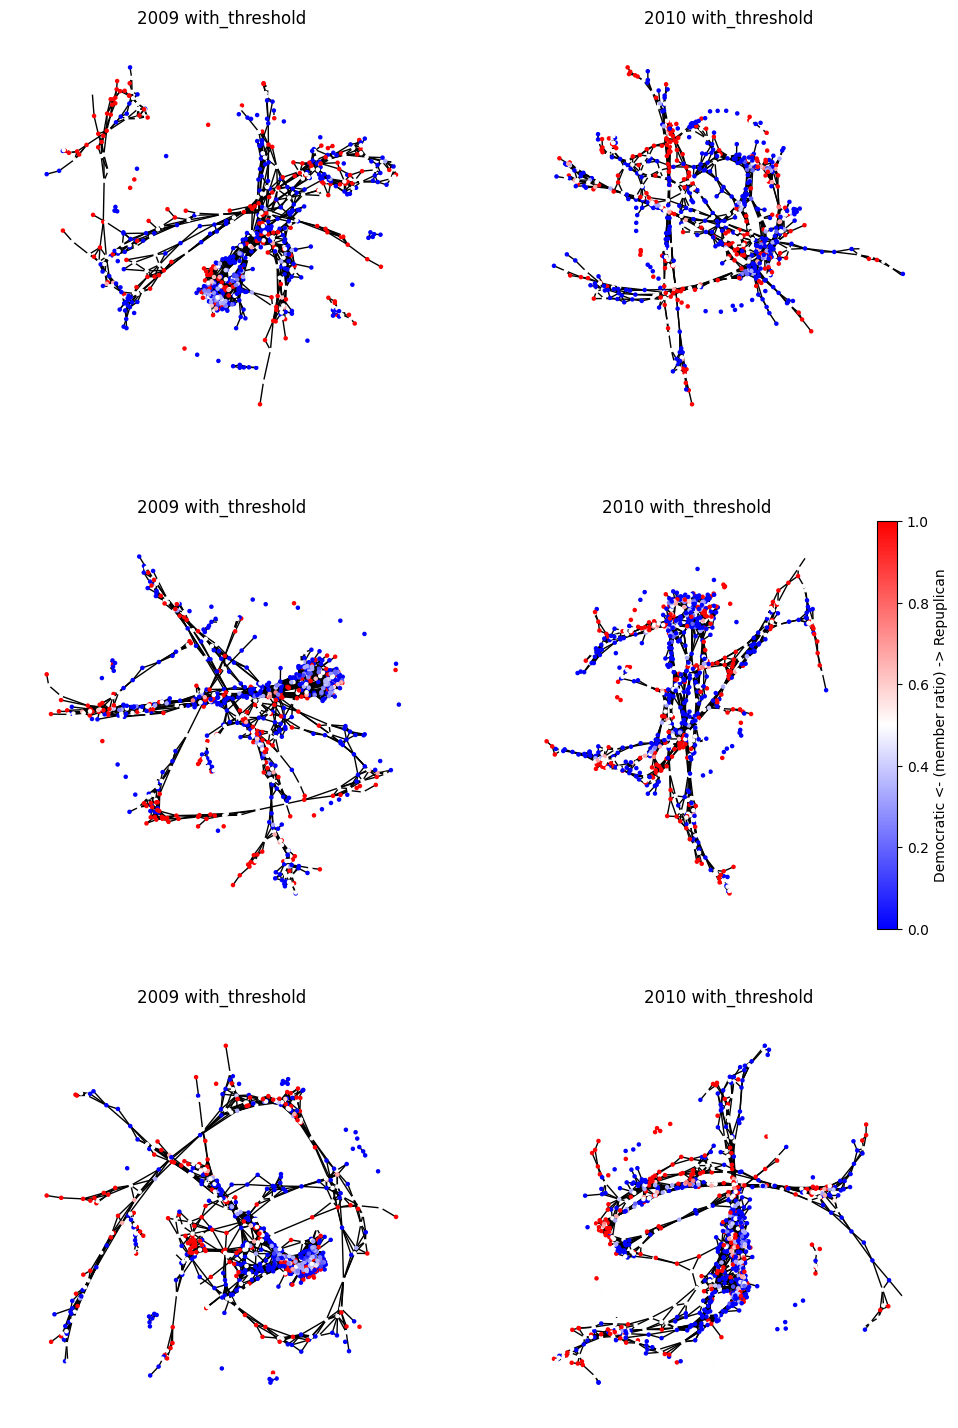

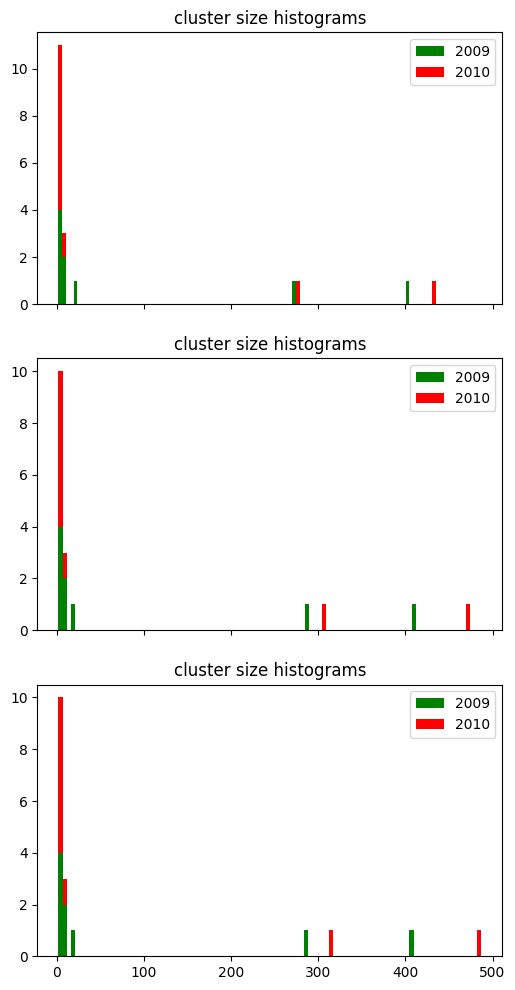

In [7]:
for name in clusterer_generators.keys():
    or_df = opti_results[opti_results["name"] == name].head(3)
    print(or_df)
    fig, axs = plt.subplots(3,2, figsize=(12,18))
    fig2, axs2 = plt.subplots(3,1, figsize=(6,12),sharex="col")

    for i in range(3):
        cluster_member_counts = []
        years = []
        colors = ["green","red"]
        for j, (year,clustering_data) in enumerate(clustering_data_per_year.items()):
            clusterer_settings = or_df["params"].iloc[i]
            clus = ClusterPipeline(
                clustering_data,
                mapper,
                clusterer_generators[name](**(clusterer_settings)),
                cover, name, clusterer_settings
            )
            clus.draw_nx_graph(axs[i,j])
            cluster_member_counts.append([cnt for cnt in clus.component_member_counts if cnt >1])
            years.append(year)
            #build_clustering(or_df["params"].iloc[i], name)
        
        axs2[i].hist(
            cluster_member_counts,
            stacked=True,
            color=colors,
            label = years,
            bins = 100
        )
        axs2[i].set_title("cluster size histograms")
        axs2[i].legend()
        
    add_cbar_right_of_axis(axs[1,1],fig)
    print(or_df)
    plt.show()
    
